In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL

# 1. Load the Excel files
# sheet_name=0 loads the first sheet 
try:
    df_sales = pd.read_excel(r"C:\Users\HP\OneDrive - PESUNIVERSITY\Documents\MBA - T2\BF - PRESENTATION TOTALNSA.xlsx", sheet_name=0)
    df_gdp = pd.read_excel(r"C:\Users\HP\OneDrive - PESUNIVERSITY\Documents\MBA - T2\BF - PRESENTATION GDPC1.xlsx", sheet_name=0)
    print("Files loaded successfully!\n")
except Exception as e:
    print(f"Error loading files: {e}")

# 2. Preview Sales Data
print("--- Automobile Sales Data Preview ---")
print(df_sales.head())
print("\nSales Columns:", df_sales.columns.tolist())

# 3. Preview GDP Data
print("\n--- Real GDP Data Preview ---")
print(df_gdp.head())
print("\nGDP Columns:", df_gdp.columns.tolist())

# 4. Check data types (Ensure dates aren't just strings)
print("\n--- Data Info ---")
df_sales.info()
df_gdp.info()

Files loaded successfully!

--- Automobile Sales Data Preview ---
  observation_date  TOTALNSA
0       1976-01-01     885.2
1       1976-02-01     994.7
2       1976-03-01    1243.6
3       1976-04-01    1191.2
4       1976-05-01    1203.2

Sales Columns: ['observation_date', 'TOTALNSA']

--- Real GDP Data Preview ---
  observation_date     GDPC1
0       1976-01-01  6323.649
1       1976-04-01  6370.025
2       1976-07-01  6404.895
3       1976-10-01  6451.177
4       1977-01-01  6527.703

GDP Columns: ['observation_date', 'GDPC1']

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  601 non-null    datetime64[ns]
 1   TOTALNSA          601 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0

Successfully merged! New total rows: 201
                     TOTALNSA     GDPC1
observation_date                       
1976-01-01        1041.166667  6323.649
1976-04-01        1216.366667  6370.025
1976-07-01        1082.100000  6404.895
1976-10-01        1091.866667  6451.177
1977-01-01        1171.033333  6527.703


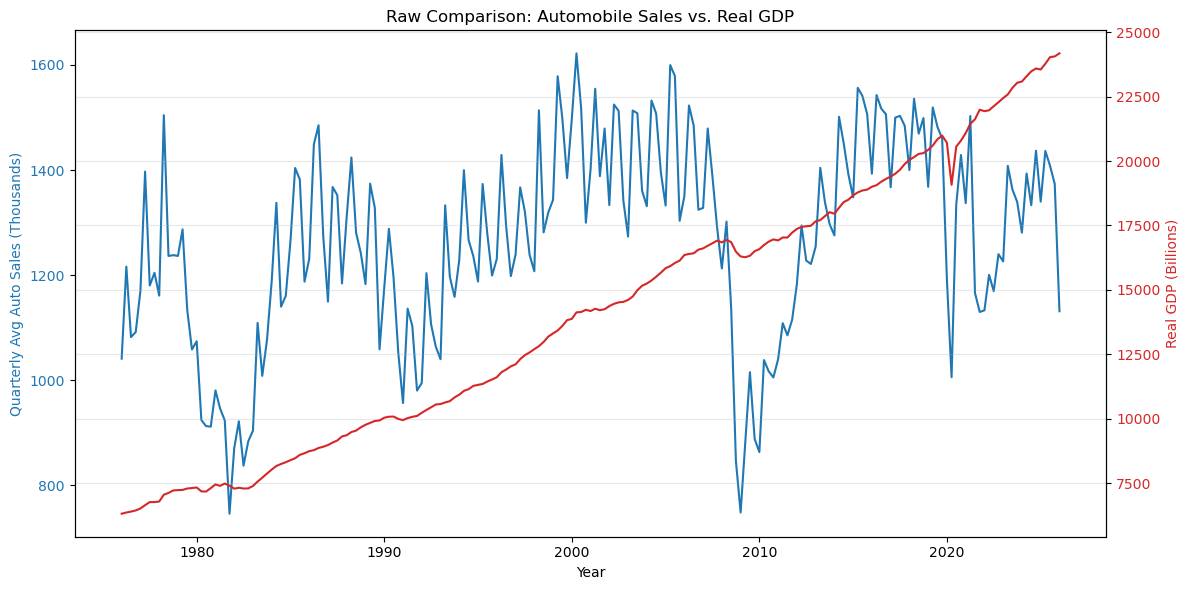

In [7]:
# 1. Set 'observation_date' as the index for both dataframes
df_sales.set_index('observation_date', inplace=True)
df_gdp.set_index('observation_date', inplace=True)

# 2. Downsampling: Monthly Sales -> Quarterly Average
# Using 'QS' (Quarter Start) to match GDP's 1st-of-the-month labeling
# This takes the average of Jan, Feb, Mar and labels it as Jan 1st
df_sales_q = df_sales['TOTALNSA'].resample('QS').mean().to_frame()

# 3. Merge both datasets into a single dataframe
# We use an 'inner' join so we only keep quarters that exist in both files
df_merged = pd.merge(df_sales_q, df_gdp, left_index=True, right_index=True, how='inner')

# 4. Preview the merged data and check the row count
print(f"Successfully merged! New total rows: {len(df_merged)}")
print(df_merged.head())

# 5. Plot the raw data to visualize the relationship
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Sales on the left axis
ax1.set_xlabel('Year')
ax1.set_ylabel('Quarterly Avg Auto Sales (Thousands)', color='tab:blue')
ax1.plot(df_merged.index, df_merged['TOTALNSA'], color='tab:blue', label='Auto Sales')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second axis for GDP on the right
ax2 = ax1.twinx()
ax2.set_ylabel('Real GDP (Billions)', color='tab:red')
ax2.plot(df_merged.index, df_merged['GDPC1'], color='tab:red', label='Real GDP')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Raw Comparison: Automobile Sales vs. Real GDP')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

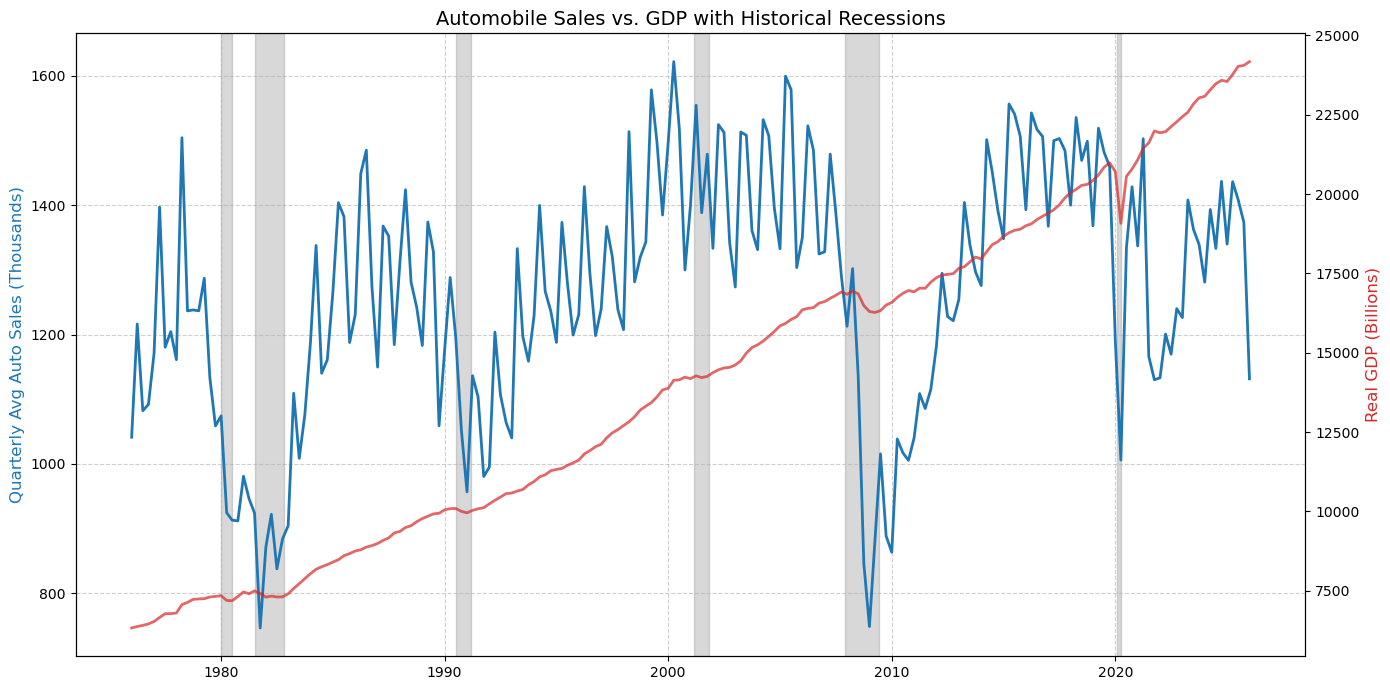

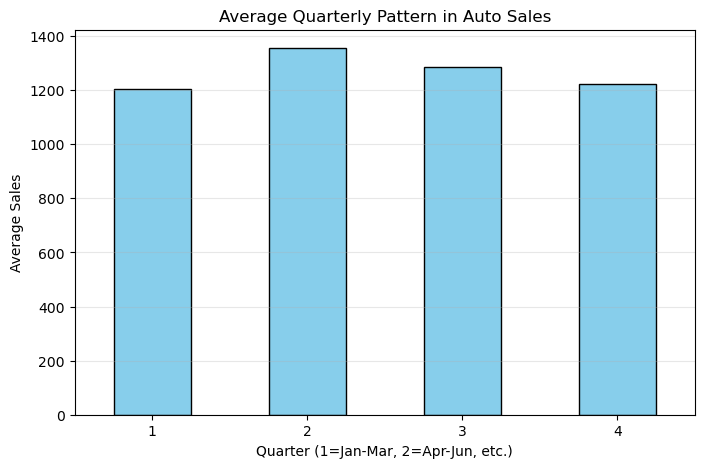

In [8]:
import matplotlib.transforms as mtransforms

# 1. Define Recession Periods (NBER Official Dates)
recessions = [
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'), # Great Recession
    ('2020-02-01', '2020-04-01')  # COVID-19
]

# 2. Plot Sales & GDP with Recession Shading
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plotting Auto Sales
ax1.plot(df_merged.index, df_merged['TOTALNSA'], color='tab:blue', lw=2, label='Auto Sales')
ax1.set_ylabel('Quarterly Avg Auto Sales (Thousands)', color='tab:blue', fontsize=12)

# Plotting GDP
ax2 = ax1.twinx()
ax2.plot(df_merged.index, df_merged['GDPC1'], color='tab:red', lw=2, alpha=0.7, label='Real GDP')
ax2.set_ylabel('Real GDP (Billions)', color='tab:red', fontsize=12)

# Add Shaded Recession Regions
for start, end in recessions:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='gray', alpha=0.3, label='Recession' if start == '2007-12-01' else "")

plt.title('Automobile Sales vs. GDP with Historical Recessions', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

# 3. Seasonal Check: Plotting the Quarterly Pattern
# We group by the quarter index (1, 2, 3, 4) to see which is typically the strongest
seasonal_pattern = df_merged['TOTALNSA'].groupby(df_merged.index.quarter).mean()

plt.figure(figsize=(8, 5))
seasonal_pattern.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Quarterly Pattern in Auto Sales')
plt.xlabel('Quarter (1=Jan-Mar, 2=Apr-Jun, etc.)')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

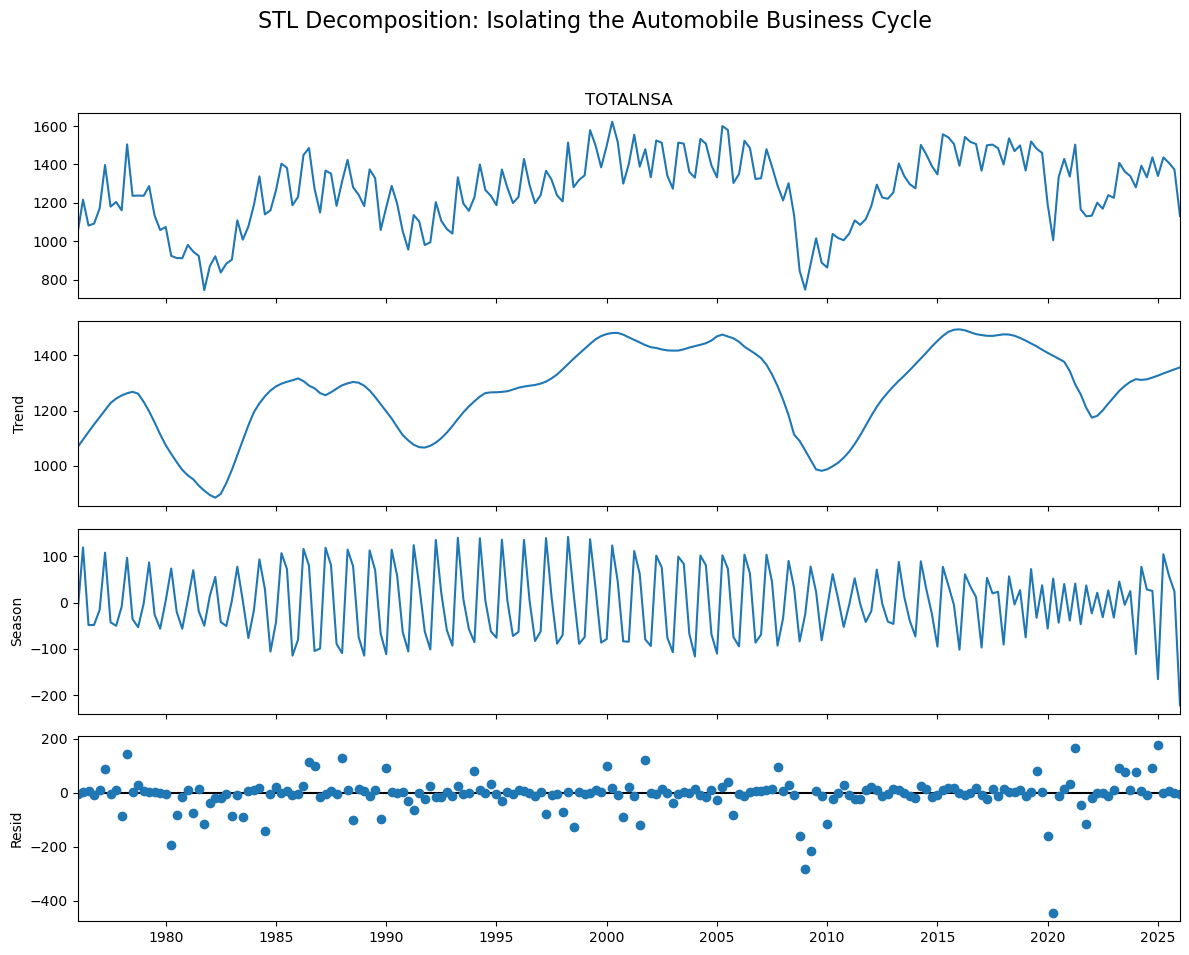

In [9]:
# 1. Perform STL Decomposition
# Period=4 because we are using the quarterly resampled data
stl = STL(df_merged['TOTALNSA'], period=4, robust=True)
result = stl.fit()

# 2. Extract components for your presentation slides
df_merged['trend'] = result.trend
df_merged['seasonal'] = result.seasonal
df_merged['resid'] = result.resid  # This contains the Business Cycle (Cyclical) + Noise

# 3. Plot all 4 components
plt.rc('figure', figsize=(12, 10))
fig = result.plot()
plt.suptitle('STL Decomposition: Isolating the Automobile Business Cycle', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


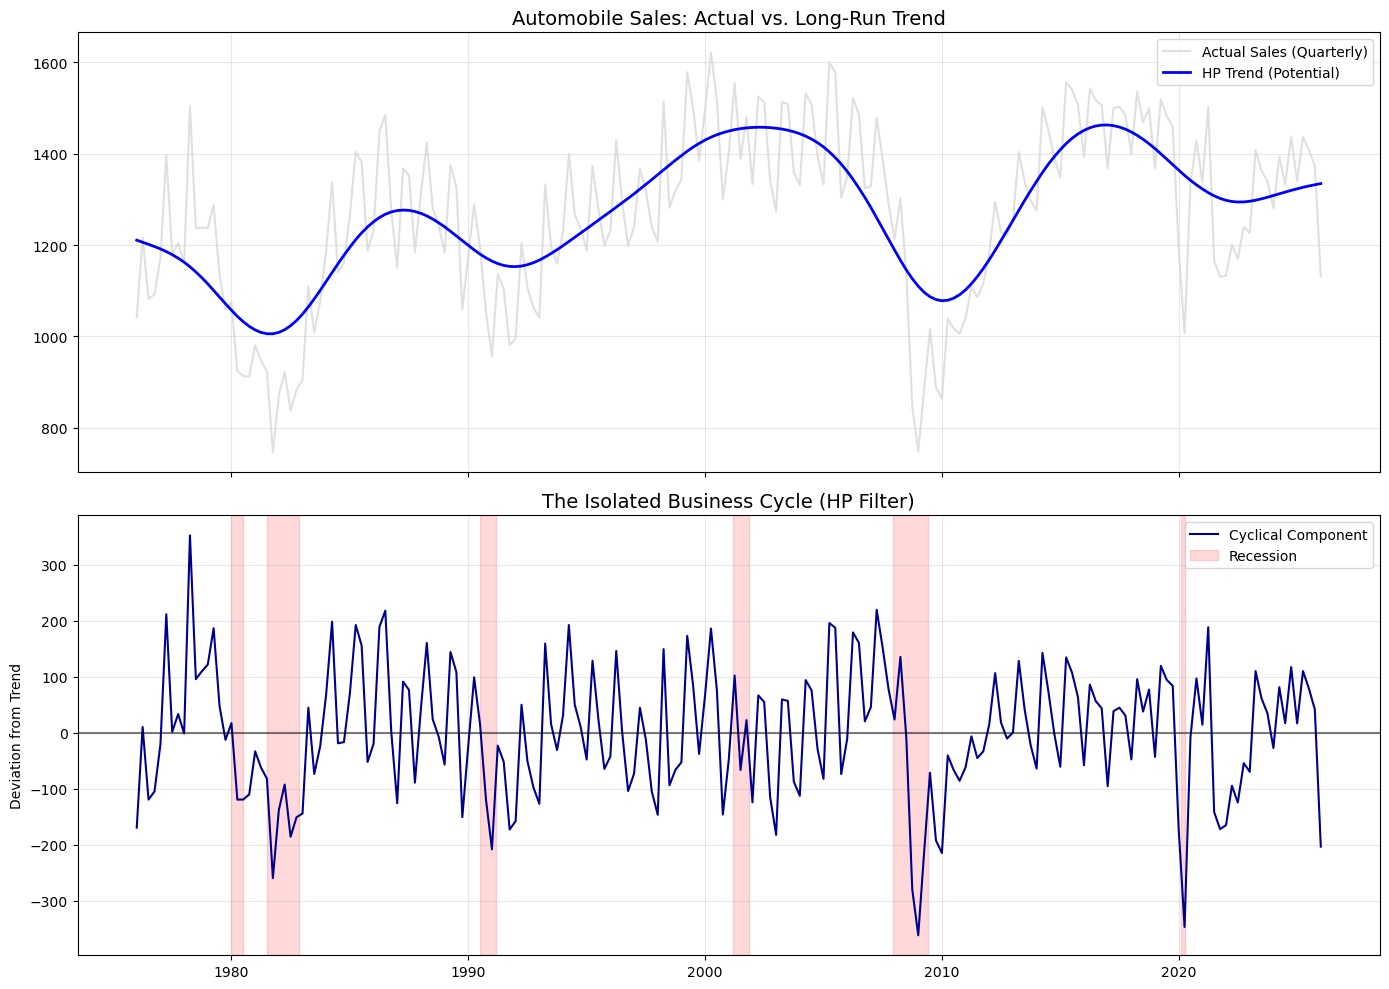

In [10]:
# 1. Apply the HP Filter
# Lambda = 1600 is the standard smoothing parameter for quarterly data
sales_cycle, sales_trend = sm.tsa.filters.hpfilter(df_merged['TOTALNSA'], lamb=1600)

# 2. Add the results to our main dataframe
df_merged['hp_trend'] = sales_trend
df_merged['hp_cycle'] = sales_cycle

# 3. Create the "Power Slide" Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top Plot: Original Data vs. HP Trend
ax1.plot(df_merged.index, df_merged['TOTALNSA'], label='Actual Sales (Quarterly)', color='lightgray', alpha=0.7)
ax1.plot(df_merged.index, df_merged['hp_trend'], label='HP Trend (Potential)', color='blue', lw=2)
ax1.set_title('Automobile Sales: Actual vs. Long-Run Trend', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom Plot: The Business Cycle (Deviation from Trend)
ax2.plot(df_merged.index, df_merged['hp_cycle'], label='Cyclical Component', color='darkblue', lw=1.5)
ax2.axhline(0, color='black', linestyle='-', alpha=0.5) # Zero line represents "Normal" growth

# Overlay Recession Markers
for start, end in recessions:
    ax2.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='red', alpha=0.15, label='Recession' if start == '2007-12-01' else "")

ax2.set_title('The Isolated Business Cycle (HP Filter)', fontsize=14)
ax2.set_ylabel('Deviation from Trend')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


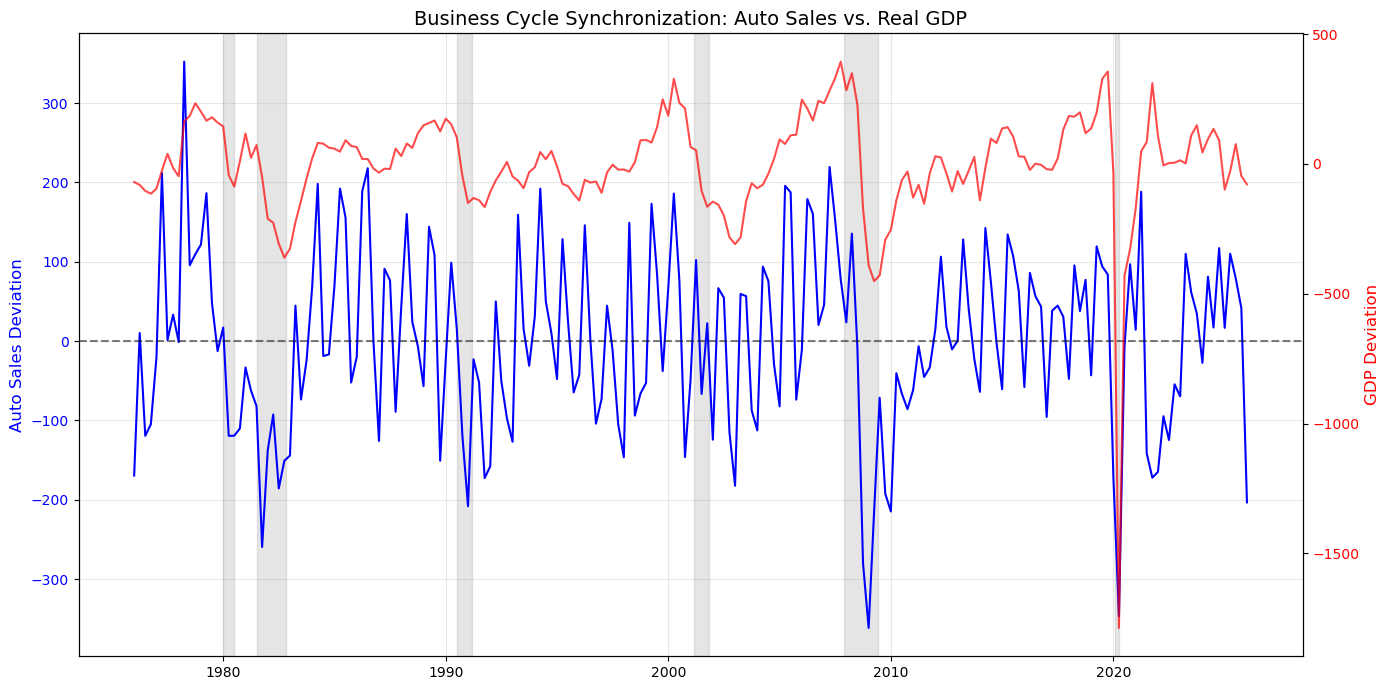

--- STATISTICAL VALIDATION ---
Correlation Coefficient: 0.4787


In [11]:
# 1. Apply HP Filter to GDP to extract the economic cycle
# We use the same lambda (1600) to ensure the cycles are comparable
gdp_cycle, gdp_trend = sm.tsa.filters.hpfilter(df_merged['GDPC1'], lamb=1600)
df_merged['gdp_cycle'] = gdp_cycle

# 2. Plot the Sales Cycle and GDP Cycle side-by-side
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Auto Sales Cycle on primary Y-axis
ax1.plot(df_merged.index, df_merged['hp_cycle'], color='blue', lw=1.5, label='Auto Sales Cycle (LHS)')
ax1.set_ylabel('Auto Sales Deviation', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Plot GDP Cycle on secondary Y-axis
ax2 = ax1.twinx()
ax2.plot(df_merged.index, df_merged['gdp_cycle'], color='red', lw=1.5, alpha=0.7, label='GDP Cycle (RHS)')
ax2.set_ylabel('GDP Deviation', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add zero line and recession shading
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
for start, end in recessions:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='gray', alpha=0.2)

plt.title('Business Cycle Synchronization: Auto Sales vs. Real GDP', fontsize=14)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# 3. Calculate the Correlation Coefficient
correlation = df_merged['hp_cycle'].corr(df_merged['gdp_cycle'])

print(f"--- STATISTICAL VALIDATION ---")
print(f"Correlation Coefficient: {correlation:.4f}")